In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage, to_tree
from scipy.stats.contingency import association
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.model_selection import KFold
import utils
from clean import load_clean, answer_text

fig_dir = "../report/figs/"

clean_df, X, questions = load_clean()
states = utils.load_states()
qcols = [c for c in clean_df.columns if c.startswith("Q")]

scores = PCA(n_components=10, random_state=42).fit_transform(X)

### k-means clustering

Clustering run on the PCA components

5-fold cross-validated silhouette score (VDS ch. 7). 
1. Split the people into 5 folds.
2. Hold out one fold and run k-means with K clusters on the other 4.
3. Assign each held-out person to the nearest of those K centers, and compute the average silhouette of the held-out people.
4. Repeat and average for each K.

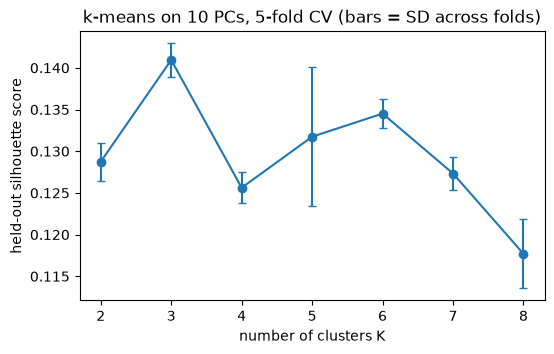

In [2]:
folds = list(KFold(n_splits=5, shuffle=True, random_state=42).split(scores))
cv_rows = []
for K in range(2, 9):
    for fold, (train, held_out) in enumerate(folds):
        kmeans = KMeans(n_clusters=K, n_init=10, random_state=42).fit(scores[train])
        held_out_labels = kmeans.predict(scores[held_out])
        silhouette = silhouette_score(scores[held_out], held_out_labels)
        cv_rows.append({"K": K, "fold": fold, "silhouette": silhouette})

cv_silhouettes = pd.DataFrame(cv_rows).groupby("K")["silhouette"].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.errorbar(cv_silhouettes.index, cv_silhouettes["mean"], yerr=cv_silhouettes["std"], fmt="o-", capsize=3)
ax.set_xlabel("number of clusters K")
ax.set_ylabel("held-out silhouette score")
ax.set_title("k-means on 10 PCs, 5-fold CV (bars = SD across folds)")
fig.savefig(fig_dir + "cluster-silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

K = 3 is highest and overall SD is small. However, the values are generally low suggesting that on average a person is slightly closer to their own cluster than to the next.

{0: 'cluster 1 (29%)', 1: 'cluster 2 (42%)', 2: 'cluster 3 (28%)'}


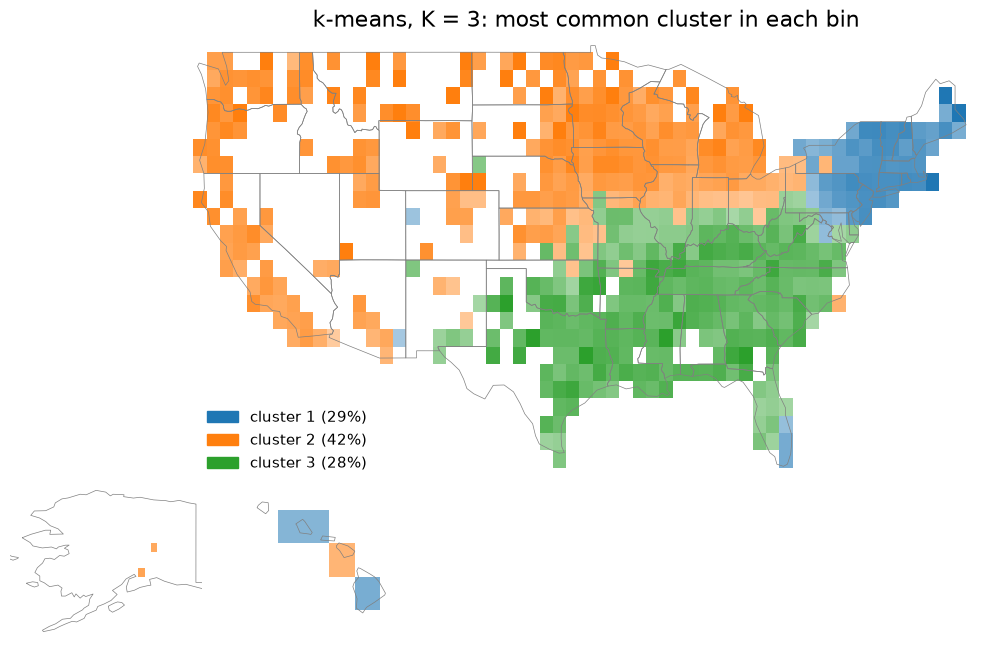

In [3]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit(scores)
labels = kmeans.labels_

sizes = pd.Series(labels).value_counts(normalize=True).sort_index() * 100
cluster_names = {c: f"cluster {c + 1} ({sizes[c]:.0f}%)" for c in range(3)}
print(cluster_names)

fig, axes = utils.map_top_label(clean_df, labels, cluster_names, states)
axes["contiguous"].set_title("k-means, K = 3: most common cluster in each bin", fontsize=16)
fig.savefig(fig_dir + "cluster-kmeans-map.png", dpi=150, bbox_inches="tight")
plt.show()

The clusters show a clear regional divide.
Cluster 1 is the Northeast, cluster 2 is Midwest and West and cluster 3 is the South.

In [4]:
cluster_percent = X.groupby(labels).mean() * 100
national_percent = X.mean() * 100
ratio = cluster_percent / national_percent

for c in range(3):
    common = cluster_percent.loc[c] >= 10
    top = ratio.loc[c, common].sort_values(ascending=False).index[:8]
    table = pd.DataFrame({
        "question": [questions[a.split("_")[0]]["question"][:70] for a in top],
        "answer": [answer_text(questions, a.split("_")[0], int(a.split("_")[1])) for a in top],
        "% in cluster": cluster_percent.loc[c, top].values,
        "% everyone": national_percent[top].values,
        "ratio": ratio.loc[c, top].values,
    }, index=[a.split("_")[0] for a in top])
    print(cluster_names[c])
    display(table.round(1))

cluster 1 (29%)


,question,answer,% in cluster,% everyone,ratio
Q093,When you stand outside with a long line of peo...,both sound equally good,11.5,3.9,2.9
Q093,When you stand outside with a long line of peo...,on line,10.3,3.6,2.9
Q110,What do you call the night before Halloween?,mischief night,26.5,9.2,2.9
Q064,What do you call the long sandwich that contai...,hero,11.4,4.2,2.7
Q106,What do you call the act of covering a house o...,I have no word for this,17.1,6.5,2.6
Q084,What do you call a traffic situation in which ...,rotary,24.8,9.8,2.5
Q083,What do you call an easy course?,gut,23.7,10.1,2.4
Q073,What is your *general* term for the rubber-sol...,sneakers,87.5,37.8,2.3


cluster 2 (42%)


,question,answer,% in cluster,% everyone,ratio
Q103,What do you call the thing from which you migh...,drinking fountain,63.1,33.6,1.9
Q105,What is your generic term for a sweetened carb...,pop,52.0,28.4,1.8
Q095,What is 'the City'?,Chicago,10.8,6.3,1.7
Q099,Which of these terms do you prefer for the sma...,frontage road,52.2,31.6,1.7
Q061,What do you call the area of grass that occurs...,boulevard,16.4,10.0,1.6
Q079,What is your *general* term for a big road tha...,freeway,19.7,12.1,1.6
Q079,What is your *general* term for a big road tha...,"a freeway has limited access (no stop lights, ...",22.0,13.7,1.6
Q076,What term do you use to refer to something tha...,kitty-corner,74.0,46.9,1.6


cluster 3 (28%)


,question,answer,% in cluster,% everyone,ratio
Q106,What do you call the act of covering a house o...,wrapping,11.3,3.6,3.1
Q106,What do you call the act of covering a house o...,rolling,17.5,5.8,3.0
Q075,What do you call the wheeled contraption in wh...,buggy,12.1,4.1,3.0
Q080,What do you call it when rain falls while the ...,the devil is beating his wife,17.2,6.1,2.8
Q050,What word(s) do you use to address a group of ...,y'all,49.2,17.5,2.8
Q099,Which of these terms do you prefer for the sma...,feeder road,10.4,3.7,2.8
Q105,What is your generic term for a sweetened carb...,coke,39.2,14.1,2.8
Q074,What do you call the little gray creature (tha...,doodle bug,14.5,5.2,2.8


We can also see what questions and answers drive each cluster by looking at the answer ratios compared to the entire dataset.

### Cluster assignment of people

Given that the silhouette score values were quite small, let's look more closely to how each person's distance to the assigned cluster center is compared to the nearest one.

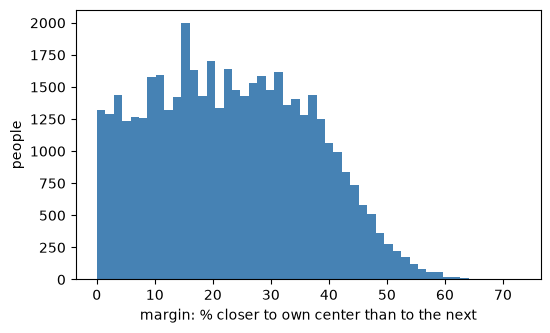

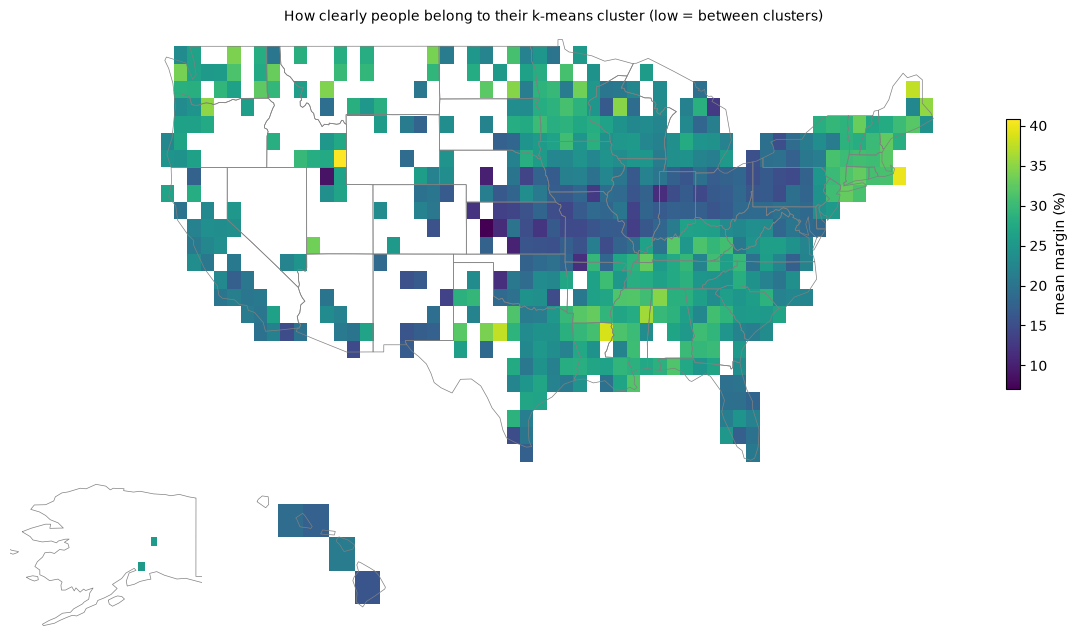

In [5]:
distances = np.sort(kmeans.transform(scores), axis=1)
margin = (distances[:, 1] - distances[:, 0]) / distances[:, 1] * 100

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(margin, bins=50, color="steelblue")
ax.set_xlabel("margin: % closer to own center than to the next")
ax.set_ylabel("people")
fig.savefig(fig_dir + "cluster-margin-hist.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = utils.map_values(clean_df, margin, states, cmap="viridis", label="mean margin (%)")
axes["contiguous"].set_title("How clearly people belong to their k-means cluster (low = between clusters)", fontsize=10)
fig.savefig(fig_dir + "cluster-margin-map.png", dpi=150, bbox_inches="tight")
plt.show()

It seems like the majority of people have small margins. On the map, we can see that the average of mean margin is higher in the South and Northeast. The borders between the three clusters clearly shown in the previous figure seem to have smaller mean margins, which suggests that the cluster identities are a continuum rather than sharp, clean divides.

### Hierarchical clustering

Now let's try Ward hierarchical clustering. Here, at each step, the two groups that add the least within-cluster variance when merged become merged. 

First trying on the random subset of 5000 people.

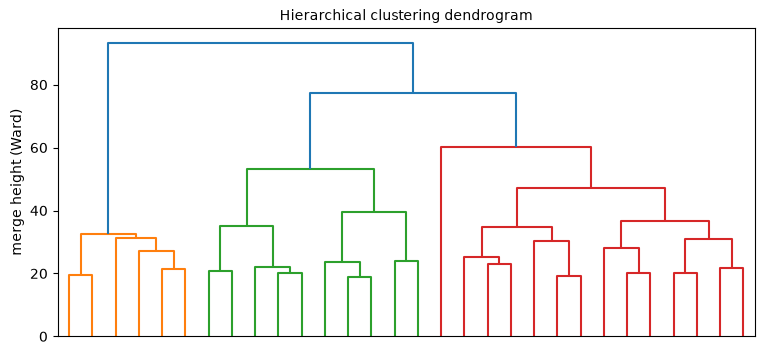

In [6]:
rng = np.random.default_rng(42)
sample = rng.choice(len(X), size=5000, replace=False)
tree = linkage(scores[sample], method="ward")

fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(tree, truncate_mode="lastp", p=30, no_labels=True, ax=ax)
ax.set_ylabel("merge height (Ward)")
ax.set_title("Hierarchical clustering dendrogram", fontsize=10)
fig.savefig(fig_dir + "cluster-ward-dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

Let's cut the tree at 3 clusters and compare with the k-means solution on the same people.

In [7]:
ward_labels = fcluster(tree, t=3, criterion="maxclust") - 1

print(f"ARI(k-means, Ward) = {adjusted_rand_score(labels[sample], ward_labels):.2f}")
print(f"Ward silhouette = {silhouette_score(scores[sample], ward_labels):.3f}, "
      f"k-means silhouette on the same people = {silhouette_score(scores[sample], labels[sample]):.3f}")

# row percentages: where each Ward cluster's people sit in k-means
crosstab = pd.crosstab(ward_labels, labels[sample], normalize="index") * 100
crosstab.index = [f"Ward {w + 1}" for w in crosstab.index]
crosstab.columns = [cluster_names[c] for c in crosstab.columns]
crosstab.round(0)

ARI(k-means, Ward) = 0.42
Ward silhouette = 0.098, k-means silhouette on the same people = 0.143


,cluster 1 (29%),cluster 2 (42%),cluster 3 (28%)
Ward 1,92.0,6.0,2.0
Ward 2,12.0,84.0,4.0
Ward 3,11.0,27.0,62.0


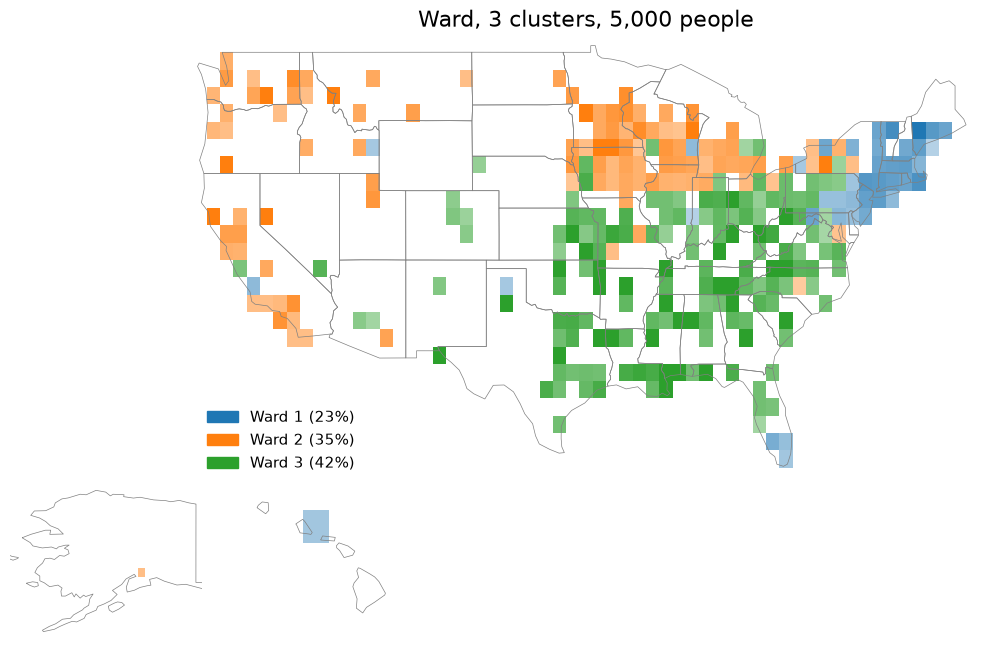

In [10]:
people = clean_df.iloc[sample]
ward_names = {w: f"Ward {w + 1} ({(ward_labels == w).mean() * 100:.0f}%)" for w in range(3)}
fig, axes = utils.map_top_label(people, ward_labels, ward_names, states, min_respondents=3)
axes["contiguous"].set_title("Ward, 3 clusters, 5,000 people",
                             fontsize=16)
fig.savefig(fig_dir + "cluster-ward-map.png", dpi=150, bbox_inches="tight")
plt.show()

So it seems like the Northeast (Cluster 1 from k-means) is also split off first in Ward. Then the rest is divided into the North and South. Ward clusters seem to show that the divide between the North and South is further north than the k-means solution. 

### Stability

Do we get the same k-means clusters if we change where k-means starts, or which people it sees? Each rerun is compared with `labels` from above using the adjusted Rand index (ARI).

**Random starts.** The clusters above keep the best of 10 starts (`n_init=10`). Here each run gets a single start, from a different seed.

In [11]:
start_ari = []
for seed in range(20):
    one_start = KMeans(n_clusters=3, n_init=1, random_state=seed).fit(scores)
    start_ari.append(adjusted_rand_score(labels, one_start.labels_))

start_ari = pd.Series(start_ari)
print(start_ari.describe().round(3))

count    20.000
mean      0.970
std       0.028
min       0.933
25%       0.939
50%       0.988
75%       0.993
max       1.000
dtype: float64


**Subsamples.** Draw 20 random 80% subsamples of people, rerun PCA and k-means on each, and compare with the original clusters of the same people.

In [12]:
subsample_rng = np.random.default_rng(42)
subsample_ari = []
for i in range(20):
    keep = subsample_rng.choice(len(X), size=int(0.8 * len(X)), replace=False)
    sub_scores = PCA(n_components=10, random_state=42).fit_transform(X.iloc[keep])
    sub_kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit(sub_scores)
    subsample_ari.append(adjusted_rand_score(labels[keep], sub_kmeans.labels_))

subsample_ari = pd.Series(subsample_ari)
print(subsample_ari.describe().round(3))

count    20.000
mean      0.985
std       0.005
min       0.976
25%       0.981
50%       0.987
75%       0.989
max       0.993
dtype: float64
